### Term Project Milestone 3: Model Building and Evaluation
### Author: Nicholas Stirling
### Date: 11/16/25
### Modified by: Nicholas Stirling

This project will be focused on analysis of US Airline Passenger Satisfaction data that can be located here: https://www.kaggle.com/datasets/johndddddd/customer-satisfaction?resource=download. Airlines need reliable, actionable insight into which operational or service levers (e.g., flight punctuality, seat comfort, in-flight service, online booking experience) most strongly influence whether a passenger rates their journey as satisfied, neutral, or dissatisfied. A robust model would allow operations, product, and customer experience teams to prioritize investments (e.g., reallocate cabin staffing, improve booking UX, target communication regarding delays) that increase satisfaction and retention — directly improving revenue through repeat business and lowering churn.

For Milestone 1, I will focus on two concrete goals: (1) define the target and features and (2) perform an exploratory graphical analysis to identify promising predictors for modeling. The target variable is the categorical Satisfaction (satisfaction, neutral, dissatisfaction). Candidate predictors include demographics (Age, Gender), trip characteristics (Flight distance, Class, Type of Travel, Customer Type), operational metrics (Departure/Arrival Delay, Flight cancelled), and a rich set of component ratings (Inflight wifi, Seat comfort, Cleanliness, Baggage handling, etc.). My approach will prioritize interpretability: start with EDA and targeting the use of logistic regression and tree-based classifier models. The logistic regression will provide clear explainable coefficients that will provide indications for affects on the satisfaction which is useful for business stakeholders. Tree-based classifier models will allow the capture of nonlinear relationships and feature interactions and our mixed data types(both numerical and categorical) and prioritized features.

Below I produced multiple labeled visualizations that begin to answer: Which features correlate with Satisfaction? Which service components show the largest mean differences between satisfied and dissatisfied passengers? Do delays and flight distance matter after accounting for service ratings?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load survey data
df_satisfaction = pd.read_excel('satisfaction.xlsx')

# Check first rows of loaded data
df_satisfaction.head()

,id,satisfaction_v2,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,11112,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,...,2,3,3,0,3,5,3,2,0,0.0
1,110278,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,...,2,3,4,4,4,2,3,2,310,305.0
2,103199,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,...,2,2,3,3,4,4,4,2,0,0.0
3,47462,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,...,3,1,1,0,1,4,1,3,0,0.0
4,120011,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,...,4,2,2,0,2,4,2,5,0,0.0


In [2]:
# Check the shape of the loaded data
df_satisfaction.shape

(129880, 24)

In [3]:
# Check the summary statistics for the data
print(df_satisfaction.describe())
print(df_satisfaction.describe(include = ['O']))

                  id            Age  Flight Distance   Seat comfort  \
count  129880.000000  129880.000000    129880.000000  129880.000000   
mean    64940.500000      39.427957      1981.409055       2.838597   
std     37493.270818      15.119360      1027.115606       1.392983   
min         1.000000       7.000000        50.000000       0.000000   
25%     32470.750000      27.000000      1359.000000       2.000000   
50%     64940.500000      40.000000      1925.000000       3.000000   
75%     97410.250000      51.000000      2544.000000       4.000000   
max    129880.000000      85.000000      6951.000000       5.000000   

       Departure/Arrival time convenient  Food and drink  Gate location  \
count                      129880.000000   129880.000000  129880.000000   
mean                            2.990645        2.851994       2.990422   
std                             1.527224        1.443729       1.305970   
min                             0.000000        0.000000    

### Observations
$\bullet$ Age data could potentially have outliers that isn't going to be indicative of larger customer based, with lowest age of 7 and max of 85.  
$\bullet$ Flight distance, Departure Delay, and Arrival Delay all have potential outliers as well outside apparent standard ranges.  
$\bullet$ Mean and standard deviations across numberical potential predictors are fairly consistent without large outlier.  
$\bullet$ No columns appear to have missing data, but there is a weighted data for Loyal customers and Business travel that will need to be accounted for.

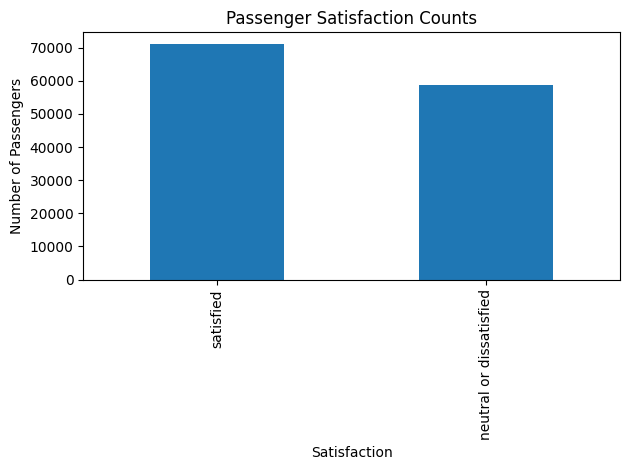

In [4]:
# 1) Bar chart: counts of Satisfaction categories
df_satisfaction['satisfaction_v2'].value_counts().plot(kind='bar')
plt.title('Passenger Satisfaction Counts')
plt.xlabel('Satisfaction')
plt.ylabel('Number of Passengers')
plt.tight_layout()
plt.show()

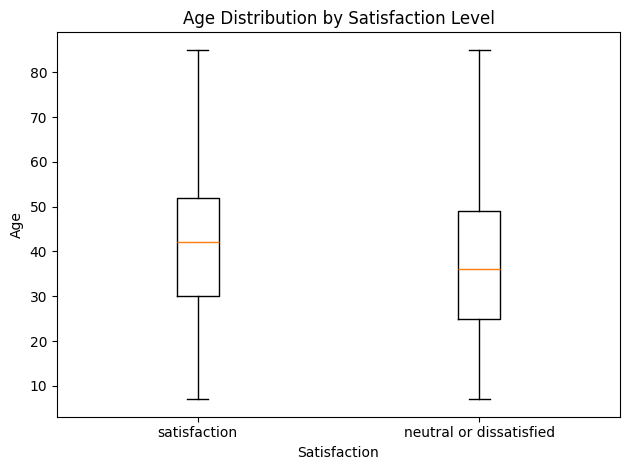

In [5]:
# 2) Age distribution by Satisfaction (boxplot)
groups = [df_satisfaction.loc[df_satisfaction['satisfaction_v2']==s, 'Age'] for s in ['satisfied','neutral or dissatisfied']]
plt.boxplot(groups, tick_labels=['satisfaction','neutral or dissatisfied'])
plt.title('Age Distribution by Satisfaction Level')
plt.xlabel('Satisfaction')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

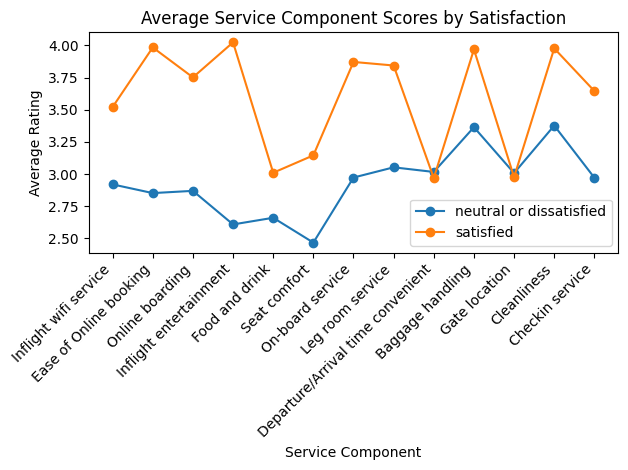

In [6]:
# 3) Mean service component scores by Satisfaction (line plot)
service_cols = [
    'Inflight wifi service','Ease of Online booking', 'Online boarding',
    'Inflight entertainment','Food and drink','Seat comfort','On-board service',
    'Leg room service','Departure/Arrival time convenient','Baggage handling','Gate location',
    'Cleanliness','Checkin service'
]
mean_by_sat = df_satisfaction.groupby('satisfaction_v2')[service_cols].mean()
for idx, sat in enumerate(mean_by_sat.index):
    plt.plot(mean_by_sat.columns, mean_by_sat.loc[sat].values, marker='o')
plt.title('Average Service Component Scores by Satisfaction')
plt.xlabel('Service Component')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Rating')
plt.legend(mean_by_sat.index)
plt.tight_layout()
plt.show()

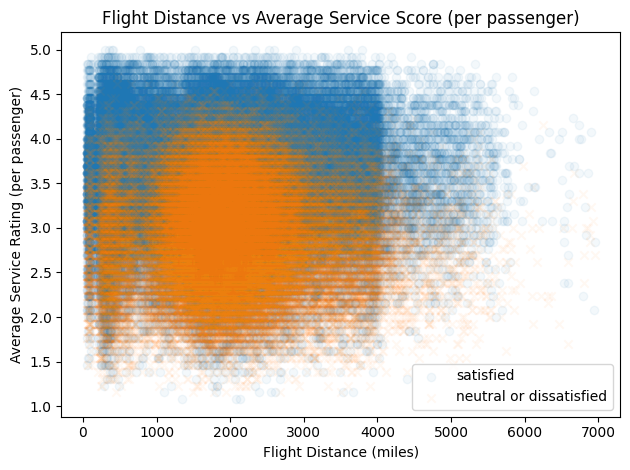

In [7]:
# 4) Scatter: Flight distance vs Mean service score (color-coded by Satisfaction using markers)
overall_service = df_satisfaction[service_cols].mean(axis=1)
markers = {'satisfied':'o', 'neutral or dissatisfied':'x'}
for sat in ['satisfied','neutral or dissatisfied']:
    sub = df_satisfaction[df_satisfaction['satisfaction_v2']==sat]
    plt.scatter(sub['Flight Distance'], overall_service[sub.index], alpha=0.05, label=sat, marker=markers[sat])
plt.title('Flight Distance vs Average Service Score (per passenger)')
plt.xlabel('Flight Distance (miles)')
plt.ylabel('Average Service Rating (per passenger)')
plt.legend()
plt.tight_layout()
plt.show()

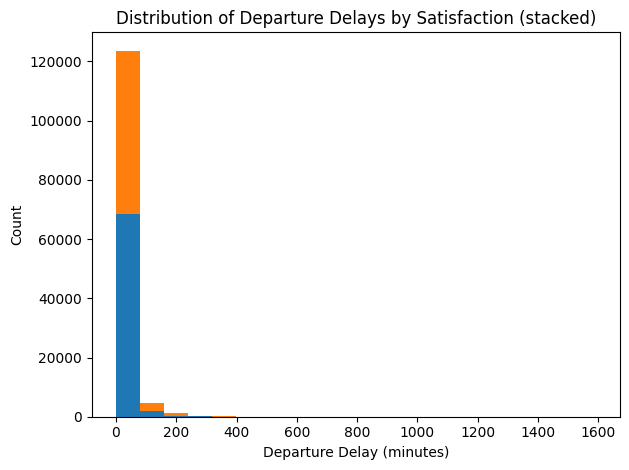

In [8]:
# 5) Histogram: Departure delays by Satisfaction
plt.hist([df_satisfaction.loc[df_satisfaction['satisfaction_v2']==s, 'Departure Delay in Minutes'] for s in ['satisfied','neutral or dissatisfied']],
         bins=20, stacked=True)
plt.title('Distribution of Departure Delays by Satisfaction (stacked)')
plt.xlabel('Departure Delay (minutes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Observations
$\bullet$ Age median are similar across the satisfaction groups and may be a weak indication as there is not a large shift across box plots.  
$\bullet$ Service indicators 'Departure/Arrival time convenient' and 'Gate location' do not have much variance between satisfaction groups and actually appear lower on average for satisfied groups then nuetral/disatisfied groups which may make them weak predictors.  
$\bullet$ The remaining service indicators (e.g., Ease of Online booking, Baggage handling, Cleanliness, Check-in) are consistently higher for satisfied passengers by a noticeable margin and look to be strong candidates for predictors.  
$\bullet$ There appears to be a consistent distribution of satisfaction to nuetral or dissatisfied customers regardless of flight distance indicating that the distance traveled does not necessarily impact satisfaction over service offered.  
$\bullet$ Departure delays are heavily skewed toward short delays and does not appear to have a higher relative share of neutral or dissatisfied ratings.

### Milestone 2 Data Preparation

In [9]:
# Drop features that have indicated limited usefulness in analysis. "Gate Location" has a low variance, "Flight cancelled" has very low occurences,
# "Flight time in minutes" appears redundant with "Flight distance", and "Arrival Delay in Minutes" is redundant with "Departure Delay in Minutes"
# which all indicate low predictive value or multicollinearity.

drop_cols = ['Gate location', 'Flight cancelled', 'Flight time in minutes', 'Arrival Delay in Minutes']
df_satisfaction = df_satisfaction.drop(columns = [col for col in drop_cols if col in df_satisfaction.columns])

print("Remaining columns after dropping:", df_satisfaction.columns.tolist())

Remaining columns after dropping: ['id', 'satisfaction_v2', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink', 'Inflight wifi service', 'Inflight entertainment', 'Online support', 'Ease of Online booking', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding', 'Departure Delay in Minutes']


In [10]:
# Review to identify 0 or NaN values across service rating categories which may indicate incomplete surveys
service_cols = [
    'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink',
    'Inflight wifi service', 'Inflight entertainment',
    'Online support', 'Ease of Online booking', 'On-board service',
    'Leg room service', 'Baggage handling', 'Checkin service',
    'Cleanliness', 'Online boarding'
]

# Identify rows where all service columns are missing or zero
incomplete_mask = df_satisfaction[service_cols].isna().all(axis=1) | (df_satisfaction[service_cols].sum(axis=1) == 0)
num_incomplete = incomplete_mask.sum()
print(f"Number of incomplete surveys (no service ratings): {num_incomplete}")

Number of incomplete surveys (no service ratings): 0


In [11]:
# Search for amount of columns with missing values in each column
missing_summary = df_satisfaction.isna().mean().sort_values(ascending=False) * 100
print("\nPercentage of missing data by column:")
print(missing_summary[missing_summary > 0])


Percentage of missing data by column:
Series([], dtype: float64)


In [12]:
# For Departure delays cap them at 600 minutes to eliminate extreme outliers
if 'Departure Delay in Minutes' in df_satisfaction.columns:
    df_satisfaction['Departure Delay in Minutes'] = df_satisfaction['Departure Delay in Minutes'].clip(upper=600)

# Check values were clipped at 600
df_satisfaction['Departure Delay in Minutes'].max()

600

In [13]:
# Create binned distance categories
if 'Flight Distance' in df_satisfaction.columns:
    df_satisfaction['Distance Category'] = pd.cut(
        df_satisfaction['Flight Distance'],
        bins=[0, 1000, 2500, np.inf],
        labels=['Short-haul', 'Medium-haul', 'Long-haul']
    )

df_satisfaction['Distance Category'].value_counts()

Distance Category
Medium-haul    73077
Long-haul      34231
Short-haul     22572
Name: count, dtype: int64

In [14]:
# One-hot encoding for categorical values 'Gender', 'Customer Type', 'Type of Travel', and 'Class'
categorical_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
categorical_cols = [col for col in categorical_cols if col in df_satisfaction.columns]

# Use pandas get_dummies for simplicity
df_encoded = pd.get_dummies(df_satisfaction, columns=categorical_cols, drop_first=True)

print("\nFinal dataset shape after encoding:", df_encoded.shape)
print("Columns after encoding:\n", df_encoded.columns)


Final dataset shape after encoding: (129880, 24)
Columns after encoding:
 Index(['id', 'satisfaction_v2', 'Age', 'Flight Distance', 'Seat comfort',
       'Departure/Arrival time convenient', 'Food and drink',
       'Inflight wifi service', 'Inflight entertainment', 'Online support',
       'Ease of Online booking', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding',
       'Departure Delay in Minutes', 'Distance Category', 'Gender_Male',
       'Customer Type_disloyal Customer', 'Type of Travel_Personal Travel',
       'Class_Eco', 'Class_Eco Plus'],
      dtype='object')


### Milestone 3 Model Building and Evaluation

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# check loaded data
df_encoded.head()

,id,satisfaction_v2,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Inflight wifi service,Inflight entertainment,Online support,...,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Distance Category,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus
0,11112,satisfied,65,265,0,0,0,2,4,2,...,5,3,2,0,Short-haul,False,False,True,True,False
1,110278,satisfied,47,2464,0,0,0,0,2,2,...,2,3,2,310,Medium-haul,True,False,True,False,False
2,103199,satisfied,15,2138,0,0,0,2,0,2,...,4,4,2,0,Medium-haul,False,False,True,True,False
3,47462,satisfied,60,623,0,0,0,3,4,3,...,4,1,3,0,Short-haul,False,False,True,True,False
4,120011,satisfied,70,354,0,0,0,4,3,4,...,4,2,5,0,Short-haul,False,False,True,True,False


In [16]:
# Create binary target value 1 =  Satisfied and 0 = neutral or dissatisfied
df = df_encoded.copy()

mapping = {
    'satisfied': 1,
    'neutral or dissatisfied': 0,
}
df['Satisfaction_binary'] = df['satisfaction_v2'].map(mapping).astype(int)

print(df.head())
print(df_encoded['satisfaction_v2'].value_counts())
print(df['Satisfaction_binary'].value_counts())

       id satisfaction_v2  Age  Flight Distance  Seat comfort  \
0   11112       satisfied   65              265             0   
1  110278       satisfied   47             2464             0   
2  103199       satisfied   15             2138             0   
3   47462       satisfied   60              623             0   
4  120011       satisfied   70              354             0   

   Departure/Arrival time convenient  Food and drink  Inflight wifi service  \
0                                  0               0                      2   
1                                  0               0                      0   
2                                  0               0                      2   
3                                  0               0                      3   
4                                  0               0                      4   

   Inflight entertainment  Online support  ...  Cleanliness  Online boarding  \
0                       4               2  ...        

In [17]:
# Separate service columns
service_cols = [
    'Inflight wifi service','Ease of Online booking','Inflight service','Online boarding',
    'Inflight entertainment','Food and drink','Seat comfort','On-board service',
    'Leg room service','Departure/Arrival time convenient','Baggage handling',
    'Gate location','Cleanliness','Check-in service'
]
service_cols = [c for c in service_cols if c in df.columns]

# Seperate operational columns
ops_cols = [c for c in [
    'Departure Delay in Minutes', 
    'Arrival Delay in Minutes', 
    'Flight Distance Log'
] if c in df.columns]

dummy_prefixes = ['Gender_', 'Customer Type_', 'Type of Travel_', 'Class_', 'Distance Category_']
dummy_cols = [c for c in df.columns if any(c.startswith(pref) for pref in dummy_prefixes)]

features = service_cols + ops_cols + dummy_cols
features = [f for f in features if f not in ['Satisfaction', 'Satisfaction_binary']]

X = df[features].copy()
y = df['Satisfaction_binary'].copy()

In [18]:
# Ensure that numeric columns are the correct data types
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
non_numeric_cols = df.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

print("\nNumeric columns detected:", numeric_cols)
print("\nNon-numeric columns detected:", non_numeric_cols)

# Convert numeric-like columns to numeric where possible
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="ignore")


Numeric columns detected: ['id', 'Age', 'Flight Distance', 'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink', 'Inflight wifi service', 'Inflight entertainment', 'Online support', 'Ease of Online booking', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding', 'Departure Delay in Minutes']

Non-numeric columns detected: ['satisfaction_v2', 'Distance Category', 'Gender_Male', 'Customer Type_disloyal Customer', 'Type of Travel_Personal Travel', 'Class_Eco', 'Class_Eco Plus', 'Satisfaction_binary']


C:\Users\Laurie\AppData\Local\Temp\ipykernel_2780\1008890872.py:10: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


In [19]:
# Check to see if there are any missing values
print("\nMissing values BEFORE handling:\n")
missing_before = df.isna().sum()
print(missing_before[missing_before > 0])


Missing values BEFORE handling:

Series([], dtype: int64)


In [20]:
# Create training and test data sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.25, 
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (97410, 17)
Test set shape: (32470, 17)


In [21]:
# Train the logistic model
model = LogisticRegression(
    max_iter=500,
    solver='lbfgs'
)

model.fit(X_train, y_train)
print("\nLogistic Regression model successfully trained.\n")


Logistic Regression model successfully trained.



In [22]:
# Identify the model feature coefficients and odds ratios
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0],
    "Odds Ratio": np.exp(model.coef_[0])
}).sort_values(by="Odds Ratio", ascending=False)

print("\nTop Indicators of Satisfaction (Odds Ratios):\n")
print(coef_df.head(15))


Top Indicators of Satisfaction (Odds Ratios):

                              Feature  Coefficient  Odds Ratio
3              Inflight entertainment     0.731008    2.077173
6                    On-board service     0.332861    1.394954
5                        Seat comfort     0.271793    1.312315
2                     Online boarding     0.260008    1.296941
7                    Leg room service     0.227754    1.255776
1              Ease of Online booking     0.176935    1.193553
9                    Baggage handling     0.139374    1.149554
10                        Cleanliness     0.098917    1.103975
11         Departure Delay in Minutes    -0.005105    0.994908
0               Inflight wifi service    -0.045326    0.955686
8   Departure/Arrival time convenient    -0.139399    0.869881
4                      Food and drink    -0.196933    0.821246
14     Type of Travel_Personal Travel    -0.615693    0.540266
15                          Class_Eco    -0.787523    0.454970
16     

In [23]:
# Create predications for the test set and evaluate model outputs
y_pred = model.predict(X_test)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=3))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0      0.817     0.813     0.815     14698
           1      0.846     0.850     0.848     17772

    accuracy                          0.833     32470
   macro avg      0.832     0.831     0.831     32470
weighted avg      0.833     0.833     0.833     32470


Confusion Matrix:

[[11949  2749]
 [ 2672 15100]]


In [25]:
from sklearn.metrics import (
    precision_score, 
    recall_score,
    f1_score,
    )
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))
print("F1 Score:", round(f1_score(y_test, y_pred), 3))

Precision: 0.846
Recall: 0.85
F1 Score: 0.848


The logistic model demonstrates a strong predictive performance distinguising satisfied and nuetral or dissatisfied passengers. The overall accuracy was 83.3% and there was a balanced precision, recall, and F1 scores (precision=0.846, recall=0.850, F1=0.848) when predicting satisfied customers. This would demonstrate consistent predictions without overfitting. The confusion matric shows consistent performance across classes as well, showing the model does well for both satisfied and dissatisfied passengers. The coeeficients and odds ratios show that Inflight entertainment is the strongest predictor for satisfaction more than doubling the odds of a customer being satisfied. On-board service, seat comfort, and online boarding were also impactful service related factors with high impact indicating focusing on cervice and comfort yields measurable improvements to customer satisfaction.